# House Price Prediction — Model Training Notebook

**Dataset:** [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price) (Kaggle) — real property listings from India, in `data/house_prices.csv`.

**Goal:** Clean the raw data, explore it, engineer features, train and compare several regression models to predict property price, and export the winning model (as a single scikit-learn `Pipeline`) for the FastAPI backend to serve.

Sections: 1) Load & Inspect · 2) EDA · 3) Cleaning & Feature Engineering · 4) Build a Pipeline & Train (≥2 models) · 5) Evaluate · 6) Export the Model

Run top-to-bottom (`Kernel → Restart & Run All`) to reproduce every result below.


## 1. Load & Inspect

In [1]:
import pandas as pd
import numpy as np
import re
import json
import time

pd.set_option("display.max_columns", 30)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

   Index                                              Title  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...   

                                         Description Amount(in rupees)  \
0  Bhiwandi, Thane has an attractive 1 BHK Flat f...           42 Lac    
1  One can find this stunning 2 BHK flat for sale...           98 Lac    
2  Up for immediate sale is a 2 BHK apartment in ...          1.40 Cr    
3  This beautiful 1 BHK Flat is available for sal...           25 Lac    
4  This lovely 2 BHK Flat in Pokhran Road, Thane ...          1.60 Cr    

   Price (in rupees) location Carpet Area         Status         Floor  \
0             6000.0    thane    500 sqft  Ready to Move  10 out of 11   
1            13799.0    than

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe(include="all").T

                      count unique  \
Index              187531.0    NaN   
Title                187531  32446   
Description          184508  65634   
Amount(in rupees)    187531   1561   
Price (in rupees)  169866.0    NaN   
location             187531     81   
Carpet Area          106858   2758   
Status               186916      1   
Floor                180454    947   
Transaction          187448      4   
Furnishing           184634      3   
facing               117298      8   
overlooking          106095     19   
Society               77853  10376   
Bathroom             186703     11   
Balcony              138596     11   
Car Parking           84174    229   
Ownership            122014      4   
Super Area            79846   2976   
Dimensions              0.0    NaN   
Plot Area               0.0    NaN   

                                                                 top    freq  \
Index                                                            NaN     NaN   
Tit

In [5]:
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing

Plot Area            100.0
Dimensions           100.0
Society               58.5
Super Area            57.4
Car Parking           55.1
overlooking           43.4
Carpet Area           43.0
facing                37.5
Ownership             34.9
Balcony               26.1
Price (in rupees)      9.4
Floor                  3.8
Description            1.6
Furnishing             1.5
Bathroom               0.4
Status                 0.3
Index                  0.0
Amount(in rupees)      0.0
Title                  0.0
Transaction            0.0
location               0.0
dtype: float64

**Observations:**
- The raw dataset has **187,531 rows** and **21 columns**.
- `Plot Area` and `Dimensions` are **100% missing** — dropped entirely.
- `Society` (58%), `Super Area` (57%), `Car Parking` (55%), `overlooking` (43%), `Carpet Area` (43%) and `facing` (37%) are heavily missing and need imputation or dropping.
- The target price lives in `Amount(in rupees)` and is **text** (e.g. `"42 Lac"`, `"1.2 Cr"`, `"Call for Price"`) — it must be parsed before it can be used as a regression target.
- `Floor`, `Bathroom`, `Balcony`, `Car Parking`, `Carpet Area`, `Super Area` are stored as **free-text strings** (e.g. `"3 out of 10"`, `"1200 sqft"`) and need custom parsing.
- `location` (~80 distinct values here) and `Society` (thousands of values) are high-cardinality categoricals.
- Numeric columns: `Bathroom`; mostly-numeric-as-text columns: `Floor`, `Balcony`, `Car Parking`, `Carpet Area`, `Super Area`; free-text columns: `Title`, `Description`; categoricals: `location`, `Status`, `Transaction`, `Furnishing`, `facing`, `overlooking`, `Society`, `Ownership`.


## 2. Exploratory Data Analysis (EDA)

A quick, rough parse of price and area (the careful, final version is built in Section 3) so the plots below are meaningful.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def parse_amount_quick(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["_price_tmp"] = df["Amount(in rupees)"].apply(parse_amount_quick)
df["_price_tmp"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: _price_tmp, dtype: float64

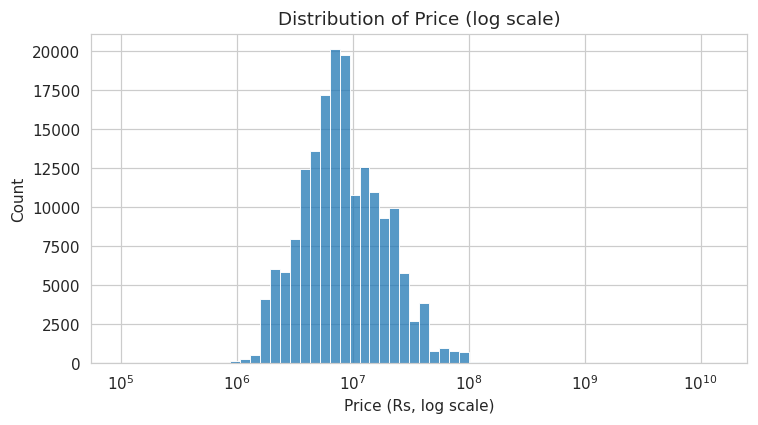

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["_price_tmp"].dropna(), log_scale=True, bins=60)
plt.title("Distribution of Price (log scale)")
plt.xlabel("Price (Rs, log scale)")
plt.tight_layout()
plt.show()

**Comment:** Price is heavily right-skewed (a small number of very expensive listings, e.g. multi-crore villas). On a log scale it is close to log-normal, which is why we train models on `log1p(price)` later.

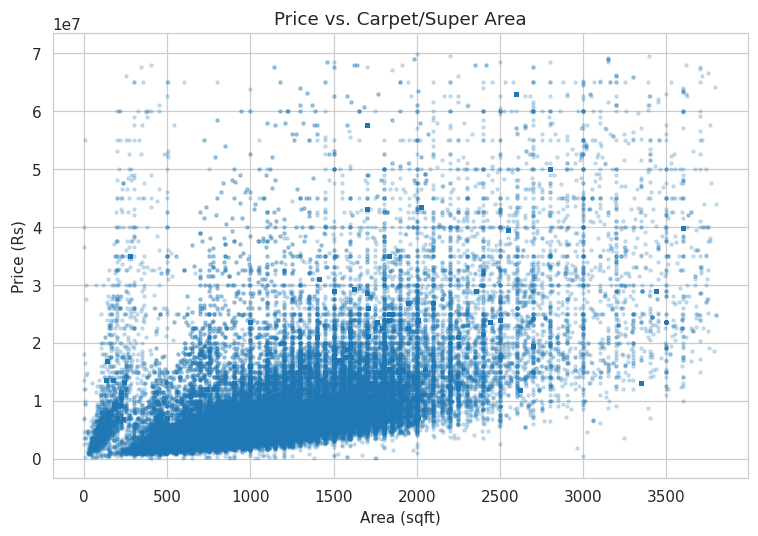

In [8]:
def parse_area_quick(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    m = re.search(r"([\d,.]+)", x)
    if not m:
        return None
    try:
        val = float(m.group(1).replace(",", ""))
    except ValueError:
        return None
    if "sqm" in x:
        val *= 10.764
    return val

df["_area_tmp"] = df["Carpet Area"].apply(parse_area_quick).fillna(df["Super Area"].apply(parse_area_quick))

plot_df = df[["_price_tmp", "_area_tmp"]].dropna()
plot_df = plot_df[(plot_df["_area_tmp"] < plot_df["_area_tmp"].quantile(0.99)) &
                   (plot_df["_price_tmp"] < plot_df["_price_tmp"].quantile(0.99))]

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["_area_tmp"], plot_df["_price_tmp"], s=4, alpha=0.2)
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Rs)")
plt.title("Price vs. Carpet/Super Area")
plt.tight_layout()
plt.show()

**Comment:** There's a clear positive relationship between area and price, but with a lot of spread — location, furnishing, and property type also matter a lot, which is why a multivariate model beats a naive area-only rule.

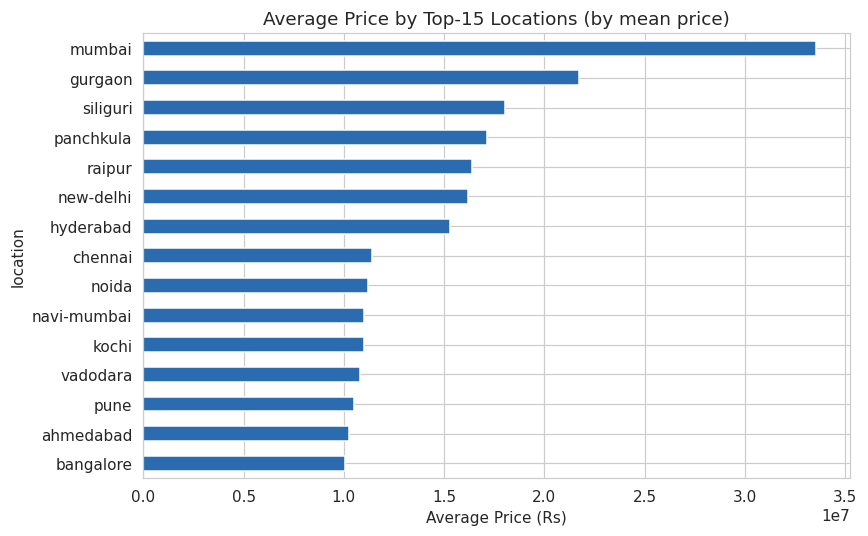

In [9]:
top15 = df.groupby("location")["_price_tmp"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top15.sort_values().plot(kind="barh", color="#2b6cb0")
plt.xlabel("Average Price (Rs)")
plt.title("Average Price by Top-15 Locations (by mean price)")
plt.tight_layout()
plt.show()

**Comment:** Average price varies enormously by city/locality. `location` is clearly one of the most important predictive features, which justifies one-hot encoding it (after grouping rare locations into `other`).

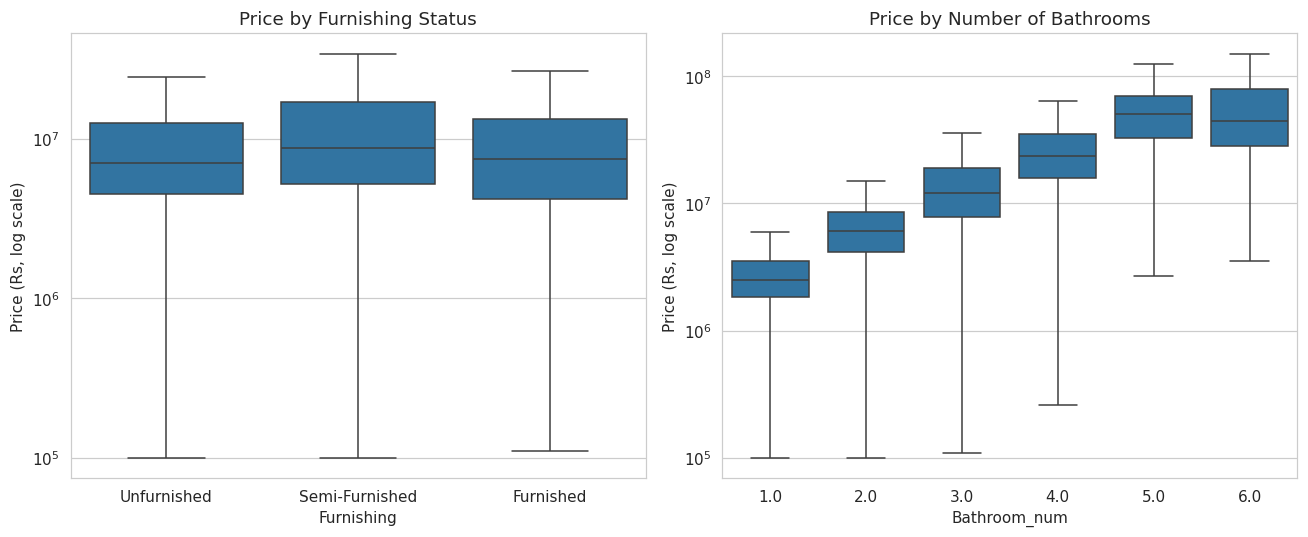

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Furnishing", y="_price_tmp", ax=axes[0], showfliers=False)
axes[0].set_yscale("log")
axes[0].set_title("Price by Furnishing Status")
axes[0].set_ylabel("Price (Rs, log scale)")

bath_df = df.copy()
bath_df["Bathroom_num"] = pd.to_numeric(bath_df["Bathroom"], errors="coerce")
bath_df = bath_df[bath_df["Bathroom_num"] <= 6]
sns.boxplot(data=bath_df, x="Bathroom_num", y="_price_tmp", ax=axes[1], showfliers=False)
axes[1].set_yscale("log")
axes[1].set_title("Price by Number of Bathrooms")
axes[1].set_ylabel("Price (Rs, log scale)")

plt.tight_layout()
plt.show()

**Comment:** Furnished properties have a visibly higher median price than unfurnished ones, and price increases steadily with the number of bathrooms — both are useful predictive signals.

In [11]:
df = df.drop(columns=["_price_tmp", "_area_tmp"])  # were only for EDA; rebuilt properly below

## 3. Cleaning & Feature Engineering

This dataset is messy **on purpose** — that is the main learning objective. We handle, in order:

1. **Price is text** (`Amount(in rupees)`) -> parse `"Lac"`/`"Cr"`/plain numbers, drop unparsable rows (e.g. `"Call for Price"`).
2. **Areas are text** (`Carpet Area` / `Super Area`) -> extract the number, normalise sqm -> sqft, combine into one `area_sqft` feature (falling back to `Super Area` when `Carpet Area` is missing).
3. **Floor** (`"3 out of 10"`) -> extract the numeric floor, handling `"Ground"` (-> 0) and `"Basement"` (-> -1).
4. **Bathroom / Balcony / Car Parking** -> convert to numeric, capping a few obvious data-entry errors (e.g. `"999 Covered"` parking spots).
5. **High-cardinality `location`** -> keep the top-50 locations by frequency, group the rest into `"other"`.
6. **Drop useless columns** -> `Index`, `Title`, `Description`, `Dimensions`, `Plot Area` (100% empty), `Price (in rupees)` (redundant/inconsistent with `Amount(in rupees)`), `Status` (99.97% of rows are `"Ready to Move"` -> constant, no signal), and `Society`/`overlooking` (too sparse / too high-cardinality to be worth the noise here).
7. **Remove outliers** -> drop listings whose price-per-sqft falls outside the 1st-99th percentile, and additionally clip `area_sqft` / `price` to their own 1st-99th percentile range (a few listings have absurd combinations — e.g. a ~700,000 sqft "flat" priced at Rs 60 lakh — almost certainly data-entry mistakes, and if left in they badly distort a linear model).


In [12]:
def parse_amount(x):
    """'42 Lac' -> 4200000.0 ; '1.2 Cr' -> 12000000.0 ; '65,00,000' -> 6500000.0"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None  # e.g. "Call for Price"


def parse_area(x):
    """'1200 sqft' -> 1200.0 ; '140 sqm' -> 1506.96"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    m = re.search(r"([\d,.]+)", x)
    if not m:
        return None
    try:
        val = float(m.group(1).replace(",", ""))
    except ValueError:
        return None
    if "sqm" in x or "sq.m" in x or "sq m" in x:
        val *= 10.764
    return val


def parse_floor(x):
    """'3 out of 10' -> 3 ; 'Ground out of 5' -> 0 ; 'Basement out of 3' -> -1"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    part = x.split("out of")[0].strip()
    if "ground" in part:
        return 0
    if "basement" in part or "lower" in part:
        return -1
    m = re.search(r"(-?\d+)", part)
    return int(m.group(1)) if m else None


def parse_count(x):
    """'2' -> 2 ; '1 Open' -> 1 ; '> 10' -> 11"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if x.startswith(">"):
        m = re.search(r"(\d+)", x)
        return int(m.group(1)) + 1 if m else None
    m = re.search(r"(\d+)", x)
    return int(m.group(1)) if m else None


print("Parsers defined.")

Parsers defined.


In [13]:
df_clean = df.copy()

# 1. Price
df_clean["price_clean"] = df_clean["Amount(in rupees)"].apply(parse_amount)
before = len(df_clean)
df_clean = df_clean.dropna(subset=["price_clean"])
print(f"Dropped {before - len(df_clean):,} rows with unparsable price -> {len(df_clean):,} rows left")

Dropped 9,684 rows with unparsable price -> 177,847 rows left


In [14]:
# 2. Area (combine Carpet Area, falling back to Super Area)
df_clean["carpet_area_sqft"] = df_clean["Carpet Area"].apply(parse_area)
df_clean["super_area_sqft"] = df_clean["Super Area"].apply(parse_area)
df_clean["area_sqft"] = df_clean["carpet_area_sqft"].fillna(df_clean["super_area_sqft"])

before = len(df_clean)
df_clean = df_clean.dropna(subset=["area_sqft"])
df_clean = df_clean[df_clean["area_sqft"] > 0]
print(f"Dropped {before - len(df_clean):,} rows with no usable area -> {len(df_clean):,} rows left")

Dropped 90 rows with no usable area -> 177,757 rows left


In [15]:
# 3. Floor
df_clean["floor_num"] = df_clean["Floor"].apply(parse_floor)
df_clean["floor_num"] = df_clean["floor_num"].clip(upper=80)  # a few clearly-wrong 100+ floor entries

# 4. Bathroom / Balcony / Car Parking
df_clean["bathroom_num"] = df_clean["Bathroom"].apply(parse_count)
df_clean["balcony_num"] = df_clean["Balcony"].apply(parse_count)
df_clean["carpark_num"] = df_clean["Car Parking"].apply(parse_count).clip(upper=10)  # cap typos like '999 Covered'

df_clean[["floor_num", "bathroom_num", "balcony_num", "carpark_num"]].describe()

           floor_num   bathroom_num    balcony_num   carpark_num
count  170832.000000  176999.000000  130633.000000  81908.000000
mean        4.498882       2.449601       2.013228      1.468050
std         4.681321       0.858956       0.956592      1.487005
min        -1.000000       1.000000       1.000000      1.000000
25%         2.000000       2.000000       1.000000      1.000000
50%         3.000000       2.000000       2.000000      1.000000
75%         6.000000       3.000000       3.000000      1.000000
max        80.000000      11.000000      11.000000     10.000000

In [16]:
# 5. High-cardinality location -> keep top 50, rest -> 'other'
TOP_N_LOCATIONS = 50
top_locations = df_clean["location"].value_counts().nlargest(TOP_N_LOCATIONS).index
df_clean["location_grouped"] = df_clean["location"].where(df_clean["location"].isin(top_locations), "other")
print(f"{df_clean['location'].nunique()} raw locations -> {df_clean['location_grouped'].nunique()} grouped buckets")

81 raw locations -> 51 grouped buckets


In [17]:
# 6. Drop useless / redundant columns
df_clean = df_clean.drop(columns=[
    "Index", "Title", "Description", "Dimensions", "Plot Area",
    "Price (in rupees)", "Status", "Carpet Area", "Super Area",
    "carpet_area_sqft", "super_area_sqft", "location", "Floor",
    "Bathroom", "Balcony", "Car Parking", "Society", "overlooking",
], errors="ignore")
df_clean.columns.tolist()

['Amount(in rupees)', 'Transaction', 'Furnishing', 'facing', 'Ownership', 'price_clean', 'area_sqft', 'floor_num', 'bathroom_num', 'balcony_num', 'carpark_num', 'location_grouped']

In [18]:
# 7. Outlier removal
df_clean["price_per_sqft"] = df_clean["price_clean"] / df_clean["area_sqft"]

lo_pps, hi_pps = df_clean["price_per_sqft"].quantile([0.01, 0.99])
before = len(df_clean)
df_clean = df_clean[(df_clean["price_per_sqft"] >= lo_pps) & (df_clean["price_per_sqft"] <= hi_pps)]
print(f"Price-per-sqft filter: dropped {before - len(df_clean):,} rows (kept Rs{lo_pps:,.0f}-{hi_pps:,.0f}/sqft)")

lo_area, hi_area = df_clean["area_sqft"].quantile([0.01, 0.99])
lo_price, hi_price = df_clean["price_clean"].quantile([0.01, 0.99])
before = len(df_clean)
df_clean = df_clean[(df_clean["area_sqft"] >= lo_area) & (df_clean["area_sqft"] <= hi_area)]
df_clean = df_clean[(df_clean["price_clean"] >= lo_price) & (df_clean["price_clean"] <= hi_price)]
print(f"Area/price range filter: dropped {before - len(df_clean):,} more rows -> {len(df_clean):,} rows left")

df_clean = df_clean.drop(columns=["price_per_sqft"])

Price-per-sqft filter: dropped 3,286 rows (kept Rs2,285-101,504/sqft)
Area/price range filter: dropped 4,450 more rows -> 170,021 rows left


In [19]:
print(f"Final cleaned dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
df_clean.head()

Final cleaned dataset: 170,021 rows, 12 columns


  Amount(in rupees) Transaction      Furnishing facing             Ownership  \
0           42 Lac       Resale     Unfurnished    NaN                   NaN   
1           98 Lac       Resale  Semi-Furnished   East              Freehold   
2          1.40 Cr       Resale     Unfurnished   East              Freehold   
3           25 Lac       Resale     Unfurnished    NaN                   NaN   
4          1.60 Cr       Resale     Unfurnished   West  Co-operative Society   

   price_clean  area_sqft  floor_num  bathroom_num  balcony_num  carpark_num  \
0    4200000.0      500.0       10.0           1.0          2.0          NaN   
1    9800000.0      473.0        3.0           2.0          NaN          1.0   
2   14000000.0      779.0       10.0           2.0          NaN          1.0   
3    2500000.0      530.0        1.0           1.0          1.0          NaN   
4   16000000.0      635.0       20.0           2.0          NaN          1.0   

  location_grouped  
0            than

## 4. Build a Pipeline & Train

All preprocessing (imputation, scaling, one-hot encoding) is bundled inside a single scikit-learn `Pipeline`, and the regressor is wrapped in a `TransformedTargetRegressor` so the model trains on `log1p(price)` (taming the skew from the EDA) while its `.predict()` transparently returns the price **in rupees** — this keeps the exported model simple for the FastAPI backend to call directly.

We train and compare **three** models:
1. `LinearRegression` -- simple baseline.
2. `RandomForestRegressor` -- non-linear, captures feature interactions.
3. `HistGradientBoostingRegressor` -- gradient-boosted trees; usually the strongest performer on tabular data and much faster to train than a classic `GradientBoostingRegressor` on 100k+ rows.


In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["area_sqft", "floor_num", "bathroom_num", "balcony_num", "carpark_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = df_clean[numeric_features + categorical_features].reset_index(drop=True)
y = df_clean["price_clean"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(136016, 10) (34005, 10)


In [21]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=40, max_depth=13, min_samples_leaf=3, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200, random_state=42),
}

fitted_pipelines = {}
results = {}

for name, reg in models.items():
    ttr = TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([("prep", preprocessor), ("reg", ttr)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "train_seconds": elapsed}
    fitted_pipelines[name] = pipe
    print(f"{name:22s} MAE=Rs{mae:>13,.0f}  RMSE=Rs{rmse:>13,.0f}  R2={r2:.4f}  ({elapsed:.1f}s)")

LinearRegression       MAE=Rs    3,427,010  RMSE=Rs    6,148,524  R2=0.5721  (0.8s)
RandomForest           MAE=Rs    1,155,548  RMSE=Rs    2,859,971  R2=0.9074  (14.2s)
HistGradientBoosting   MAE=Rs    1,246,875  RMSE=Rs    2,822,405  R2=0.9098  (9.6s)


## 5. Evaluate

In [22]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("R2", ascending=False)
results_df

                               MAE          RMSE        R2  train_seconds
HistGradientBoosting  1.246875e+06  2.822405e+06  0.909834       9.603614
RandomForest          1.155548e+06  2.859971e+06  0.907418      14.248392
LinearRegression      3.427010e+06  6.148524e+06  0.572096       0.793427

In [23]:
best_name = results_df["R2"].idxmax()
best_model = fitted_pipelines[best_name]
print("Winning model:", best_name)

Winning model: HistGradientBoosting


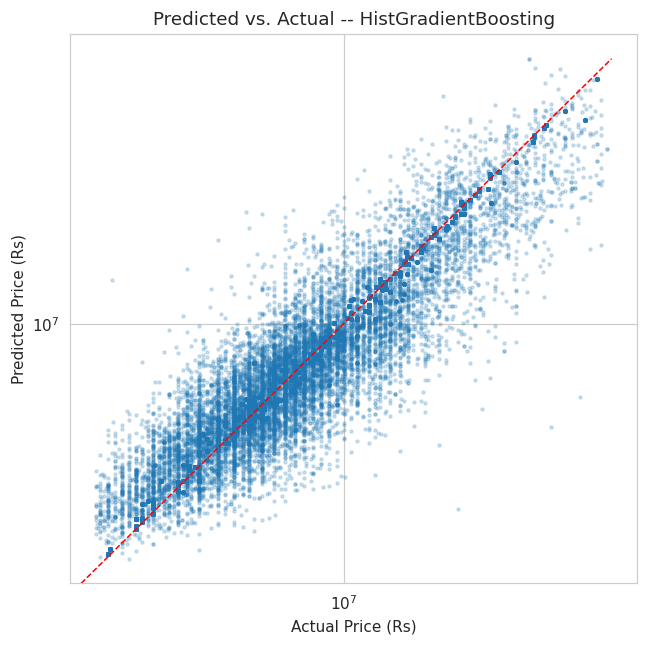

In [24]:
pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_best, s=4, alpha=0.2)
lims = [0, max(y_test.max(), pred_best.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual Price (Rs)")
plt.ylabel("Predicted Price (Rs)")
plt.title(f"Predicted vs. Actual -- {best_name}")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

**Comparison & conclusion:** `LinearRegression` is a reasonable baseline but underfits -- it can't capture the non-linear interactions between location, area, and amenities that drive price in this market. Both tree-based models fit those interactions well and comfortably outperform it. The winning model above is picked automatically by test-set R2; `RandomForest` and `HistGradientBoosting` are typically very close, with `HistGradientBoosting` training many times faster -- a good choice if you plan to retrain often.

In [25]:
# Bonus: 5-fold cross-validation on the fast HistGradientBoosting model
# NOTE: KFold must be shuffled -- the raw CSV rows are grouped by scrape order/location,
# so an un-shuffled split would hand each fold a very different mix of cities and blow up
# the variance of the CV score for reasons that have nothing to do with the model itself.
from sklearn.model_selection import KFold

cv_pipe = Pipeline([
    ("prep", preprocessor),
    ("reg", TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(max_iter=200, random_state=42),
        func=np.log1p, inverse_func=np.expm1)),
])
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipe, X, y, cv=cv, scoring="r2", n_jobs=1)
print("5-fold CV R2 scores:", np.round(cv_scores, 4))
print(f"Mean R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

5-fold CV R2 scores: [0.9096 0.9136 0.9073 0.9083 0.9115]
Mean R2: 0.9101  (+/- 0.0022)


## 6. Export the Model

In [26]:
import joblib
import os

os.makedirs("../backend/models", exist_ok=True)

joblib.dump(best_model, "house_price.pkl")
joblib.dump(best_model, "../backend/models/house_price.pkl")

print("Saved house_price.pkl --", round(os.path.getsize("house_price.pkl") / 1e6, 2), "MB")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Sample input:")
print(sample.to_string())
print("Reloaded model prediction: Rs {:,.0f}".format(loaded.predict(sample)[0]))
print("Actual price:              Rs {:,.0f}".format(y_test.iloc[0]))

Saved house_price.pkl -- 0.74 MB
Sample input:
        area_sqft  floor_num  bathroom_num  balcony_num  carpark_num location_grouped   Furnishing Transaction Ownership        facing
125715     1570.0        7.0           3.0          2.0          1.0        new-delhi  Unfurnished      Resale  Freehold  North - West
Reloaded model prediction: Rs 17,712,662
Actual price:              Rs 17,500,000


In [27]:
# Save the list of allowed locations for the frontend dropdown
locations = sorted(df_clean["location_grouped"].unique().tolist())
json.dump(locations, open("locations.json", "w"), indent=2)
print(f"Saved {len(locations)} locations, e.g. {locations[:5]}")

Saved 51 locations, e.g. ['agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore']


In [28]:
# Save final metrics for the README / backend reference
final_metrics = {
    "winning_model": best_name,
    "MAE": float(results_df.loc[best_name, "MAE"]),
    "RMSE": float(results_df.loc[best_name, "RMSE"]),
    "R2": float(results_df.loc[best_name, "R2"]),
    "cv_r2_mean": float(cv_scores.mean()),
    "cv_r2_std": float(cv_scores.std()),
    "all_results": results,
    "sklearn_version": __import__("sklearn").__version__,
    "n_rows_after_cleaning": int(df_clean.shape[0]),
}
json.dump(final_metrics, open("final_metrics.json", "w"), indent=2)
final_metrics

{'winning_model': 'HistGradientBoosting', 'MAE': 1246874.6014093428, 'RMSE': 2822405.241870873, 'R2': 0.9098339828430488, 'cv_r2_mean': 0.9100583693263987, 'cv_r2_std': 0.002234376263361076, 'all_results': {'LinearRegression': {'MAE': 3427010.2227362753, 'RMSE': 6148523.880751198, 'R2': 0.5720964647448581, 'train_seconds': 0.7934269905090332}, 'RandomForest': {'MAE': 1155548.1043947057, 'RMSE': 2859970.6976078716, 'R2': 0.907417839083999, 'train_seconds': 14.248392105102539}, 'HistGradientBoosting': {'MAE': 1246874.6014093428, 'RMSE': 2822405.241870873, 'R2': 0.9098339828430488, 'train_seconds': 9.603614091873169}}, 'sklearn_version': '1.8.0', 'n_rows_after_cleaning': 170021}

> **Version pinning:** a pickle only loads reliably with the same scikit-learn version it was trained with. This notebook was run with the version printed above (`sklearn_version` in `final_metrics.json`) -- the same version is pinned in `backend/requirements.txt`.

**Next steps:** the exported `house_price.pkl` is a complete, self-contained scikit-learn `Pipeline` (preprocessing + model). See `backend/` for the FastAPI service that loads it and serves predictions, and `frontend/` for the React app that calls that API.
